# DATA CLEANING:

In [ ]:
import pandas as pd
import re
import os

# 1. LOAD DATA
df = pd.read_excel("Student Spending Behavior & Lifestyle Survey  (Responses).xlsx")

print("Original Shape:", df.shape)

df = df.drop_duplicates()
df = df.dropna(how='all')
df.columns = df.columns.str.strip()

print("After basic cleaning:", df.shape)
print("\nColumns:\n", df.columns)


# Monthly Spending
df['2. Monthly_spending'] = df['2. Monthly_spending'].astype(str)
df['2. Monthly_spending'] = df['2. Monthly_spending'].str.replace('₹', '', regex=False)
df['2. Monthly_spending'] = df['2. Monthly_spending'].str.replace(',', '', regex=False)
df['2. Monthly_spending'] = df['2. Monthly_spending'].str.replace(' ', '', regex=False)
df['2. Monthly_spending'] = df['2. Monthly_spending'].str.replace('–', '-', regex=False)

# Savings
df['Savings'] = df['Savings'].astype(str)
df['Savings'] = df['Savings'].str.replace('₹', '', regex=False)
df['Savings'] = df['Savings'].str.replace(',', '', regex=False)
df['Savings'] = df['Savings'].str.replace(' ', '', regex=False)
df['Savings'] = df['Savings'].str.replace('–', '-', regex=False)

# Eat Out
df['Eat_Out'] = df['Eat_Out'].astype(str)
df['Eat_Out'] = df['Eat_Out'].str.replace(' ', '', regex=False)
df['Eat_Out'] = df['Eat_Out'].str.replace('–', '-', regex=False)



# Monthly Spending
def convert_spending(x):
    nums = re.findall(r'\d+', str(x))
    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return int(nums[0])
    else:
        return 0

df['Spending_num'] = df['2. Monthly_spending'].apply(convert_spending)


# Savings
def convert_savings(x):
    nums = re.findall(r'\d+', str(x))
    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2
    elif len(nums) == 1:
        return int(nums[0])
    else:
        return 0

df['Savings_num'] = df['Savings'].apply(convert_savings)


# Eat Out
def convert_eatout(x):
    x = str(x).strip()

    if '0-1' in x:
        return 1
    elif '2-4' in x:
        return 3
    elif '4-7' in x:
        return 6
    elif '>7' in x:
        return 8
    else:
        return 0

df['EatOut_num'] = df['Eat_Out'].apply(convert_eatout)



# Clean Gender text
df['Gender'] = df['Gender'].astype(str).str.strip().str.capitalize()

# Encode Gender
df['Gender_num'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

# Handle missing values
df['Gender_num'] = df['Gender_num'].fillna(0).astype(int)



print("\nFinal Shape:", df.shape)

print("\nSample Data:")
print(df[['Gender','Gender_num',
          '2. Monthly_spending','Spending_num',
          'Savings','Savings_num',
          'Eat_Out','EatOut_num']].head())



file_name = "Final_Cleaned_Student_Data.xlsx"

if os.path.exists(file_name):
    try:
        os.remove(file_name)
    except PermissionError:
        print("Close the Excel file and run again.")

try:
    df.to_excel(file_name, index=False)
    print("\n Cleaned data saved successfully!")
except PermissionError:
    print("Permission Error: Close Excel file and retry.")

FileNotFoundError: [Errno 2] No such file or directory: 'Student Spending Behavior & Lifestyle Survey  (Responses).xlsx'

# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Final_Cleaned_Student_Data.xlsx")
# 1. OVERVIEW

print("Shape:", df.shape)
print(df.info())
print(df.describe())


Shape: (118, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Timestamp            118 non-null    datetime64[ns]
 1   Gender               118 non-null    object        
 2   age                  118 non-null    int64         
 3   2. Monthly_spending  118 non-null    object        
 4   Main_Category        118 non-null    object        
 5   Online_Shopping      118 non-null    object        
 6   Influence            118 non-null    object        
 7   Budget               118 non-null    object        
 8   Savings              118 non-null    object        
 9   Overspend_Freq       118 non-null    object        
 10  Overspend_Reason     118 non-null    object        
 11  Eat_Out              118 non-null    object        
 12  Entertainment        118 non-null    object        
 13  Awareness         

### 1.Violin Plot

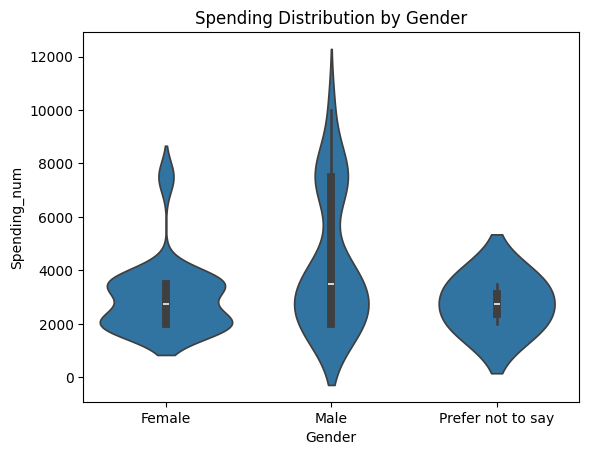

In [ ]:
sns.violinplot(x='Gender', y='Spending_num', data=df)
plt.title("Spending Distribution by Gender")
plt.show()

Insights:

Spending distribution varies across gender

Some groups show wider variability in spending

Majority of students fall within a mid spending range

### 2. SPENDING VS SAVINGS DENSITY (KDE PLOT)

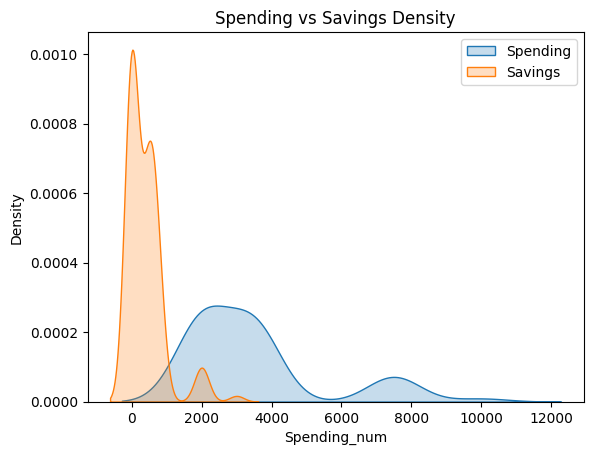

In [ ]:
sns.kdeplot(df['Spending_num'], label='Spending', fill=True)
sns.kdeplot(df['Savings_num'], label='Savings', fill=True)
plt.title("Spending vs Savings Density")
plt.legend()
plt.show()

Insight:

Spending values are more widely distributed than savings.

Savings are concentrated in lower ranges.

This suggests students prioritize spending over saving.

### 3. SPENDING VS SAVINGS RELATIONSHIP (SCATTER PLOT)

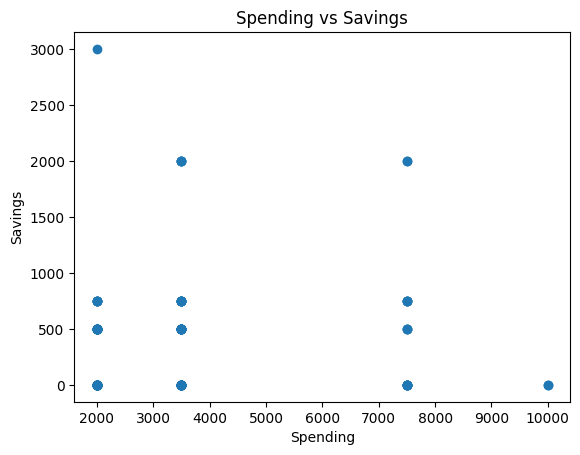

In [ ]:
plt.scatter(df['Spending_num'], df['Savings_num'])
plt.title("Spending vs Savings")
plt.xlabel("Spending")
plt.ylabel("Savings")
plt.show()

Insight:

There is no strong direct relationship between spending and savings.

Some students save even with higher spending.

This reflects varied financial behavior among individuals.

### 4.Spending Distribution by BINS (Histogram with categories)

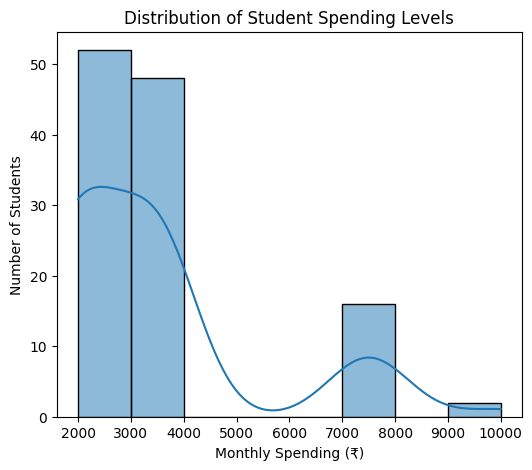

In [ ]:
plt.figure(figsize=(6,5))

sns.histplot(df['Spending_num'], bins=8, kde=True)

plt.xlabel("Monthly Spending (₹)")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Spending Levels")

plt.show()

insight:

Most students have mid-range spending patterns.

The distribution is slightly right-skewed with few high spenders.

Overall, spending is moderate with limited extreme values.

# DATA VISUALIZATION / DASHBOARDING

### 1.IMPACT OF EATING OUT ON SPENDING (REGRESSION PLOT)

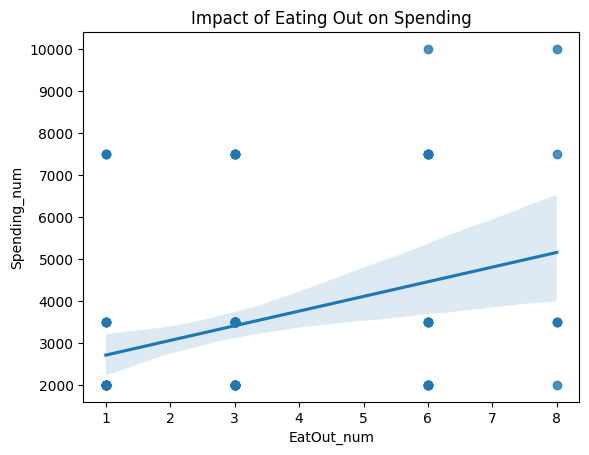

In [ ]:
sns.regplot(x='EatOut_num', y='Spending_num', data=df)
plt.title("Impact of Eating Out on Spending")
plt.show()

insight:

There is a positive trend between eating out frequency and spending.

Students who eat out more tend to spend more overall.

This highlights the impact of lifestyle habits on financial behavior.

### 2. SPENDING DENSITY DISTRIBUTION (KDE PLOT)

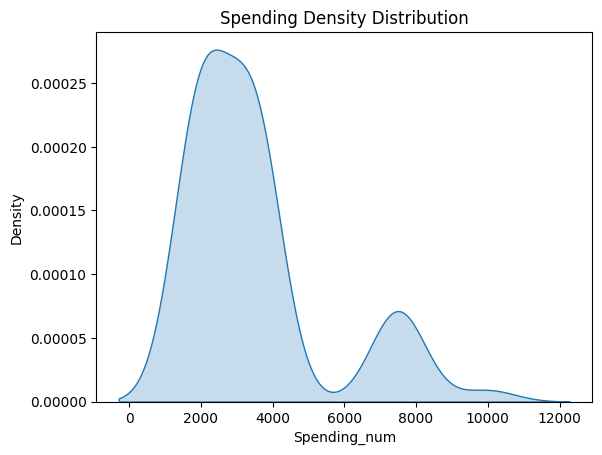

In [ ]:
sns.kdeplot(df['Spending_num'], fill=True)
plt.title("Spending Density Distribution")
plt.show()


insight:

Most students fall in mid-range spending

Distribution is slightly right-skewed

Few students are high spenders

### 3. SAVINGS SPREAD AND OUTLIERS (BOXPLOT)

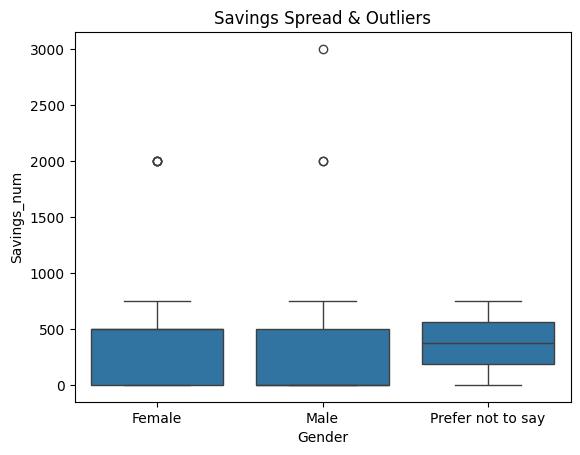

In [ ]:
sns.boxplot(x='Gender', y='Savings_num', data=df)
plt.title("Savings Spread & Outliers")
plt.show()

insight:

Savings values show significant variation across students.

The presence of outliers indicates some students save unusually high or low amounts.

Most students are concentrated in lower savings ranges.

### 4. SAVINGS TREND VS EATING OUT (LINEPLOT)


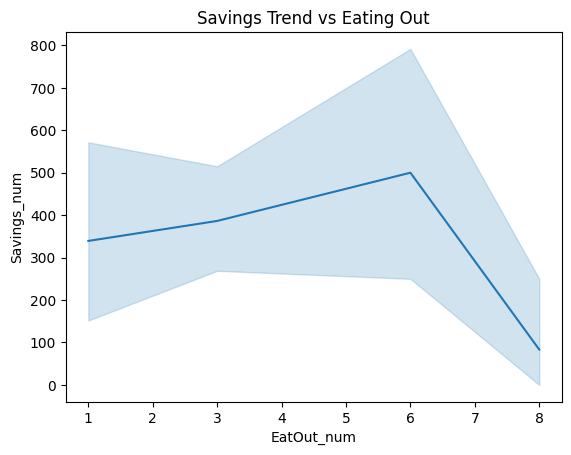

In [ ]:
sns.lineplot(x='EatOut_num', y='Savings_num', data=df)
plt.title("Savings Trend vs Eating Out")
plt.show()

insight:

Savings fluctuate as eating out frequency increases.

Higher eating out does not guarantee higher savings.

This indicates inconsistent financial management among students.

### 5.CORRELATION ANALYSIS (HEATMAP)

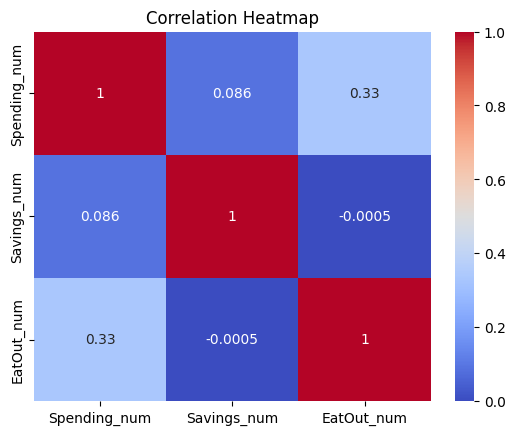

In [ ]:
sns.heatmap(df[['Spending_num','Savings_num','EatOut_num']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

insight:

The heatmap shows a positive correlation between eating out frequency and spending.

Savings have a weak relationship with both spending and eating habits.

Overall, lifestyle factors influence spending more than savings behavior.

# Basic Model Building

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score


features = ['Savings_num', 'EatOut_num', 'Gender_num']

df_model = df[['Spending_num'] + features].dropna()

df_model.head()

#Define X and y
X = df_model[features]
y = df_model['Spending_num']

### Train Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Predictions

In [ ]:
y_pred = model.predict(X_test)

### Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" FINAL MODEL PERFORMANCE")
print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 3))

🔥 FINAL MODEL PERFORMANCE
MAE: 1400.33
R² Score: 0.256


### Actual vs Predicted Plot

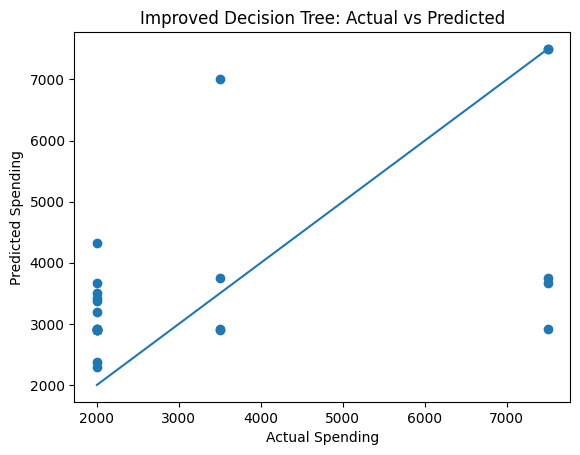

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Spending")
plt.ylabel("Predicted Spending")
plt.title("Improved Decision Tree: Actual vs Predicted")

plt.show()

### Residual Plot

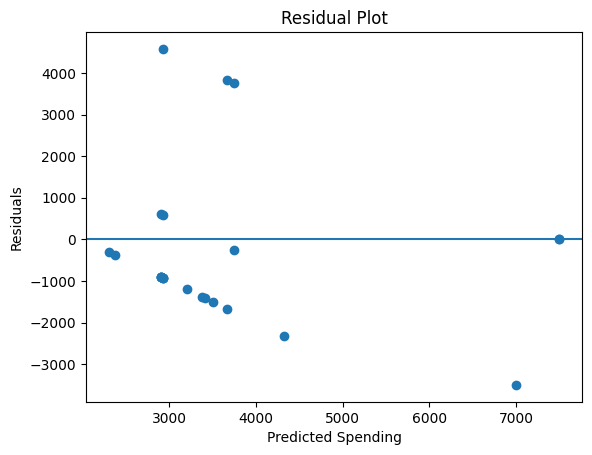

In [ ]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Spending")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()